# **Heart Disease Prediction Using Logistic Regression**

In [1]:
import pandas as pd

import numpy as np

import statsmodels.api as sm

import matplotlib.pyplot as plt

import seaborn as sns

from scipy import stats

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

**Dataset source: UCI Machine Learning Repository**

In [2]:
!pip install ucimlrepo

In [3]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
heart_disease = fetch_ucirepo(id=45)

# data (as pandas dataframes)
X = heart_disease.data.features
y = heart_disease.data.targets
y = (y>0).astype(int)

# **Project Objectives**

o Load the dataset and perform necessary data preprocessing steps, including handling missing values and encoding categorical variables.
   
o Explore the data to understand the distribution of variables and the relationship between features and the target variable.

o Fit an appropriate regression model using the features to predict the presence of heart disease.

o Evaluate the model's performance using appropriate metrics like accuracy, precision and recall.

o Interpret the model's coefficients to understand the influence of each feature on the likelihood of having heart disease.



# **The data**

First we output the two data to see the features

In [ ]:
X.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0


In [ ]:
y.head()

,num
0,0
1,1
2,1
3,0
4,0


# **Data Cleaning**

The X dataset (features) contains different information that that can be used to predict heart disease while the response variable seems to have 1 and 0 entries (presence or absence of heart disease.) We can concatenate them to obtain a single dataset.

In [ ]:
heart_disease = pd.concat([X, y], axis=1)
heart_disease.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


We check for any duplicates or missing data.

In [ ]:
print(X.duplicated().sum()) #returns 0 as duplicates


0


In [ ]:
heart_disease.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  num       303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


The columns ca and thal have 4 and 2 missing datapoints respectively. We could identify where the missing data are located.

In [ ]:
# Identifying the rows with missing data
null_data = heart_disease[heart_disease['ca'].isnull() | heart_disease['thal'].isnull()]
null_data

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
87,53,0,3,128,216,0,2,115,0,0.0,1,0.0,NaN,0
166,52,1,3,138,223,0,0,169,0,0.0,1,NaN,3.0,0
192,43,1,4,132,247,1,2,143,1,0.1,2,NaN,7.0,1
266,52,1,4,128,204,1,0,156,1,1.0,2,0.0,NaN,1
287,58,1,2,125,220,0,0,144,0,0.4,2,NaN,7.0,0
302,38,1,3,138,175,0,0,173,0,0.0,1,NaN,3.0,0


We have made a decision to drop all the null entries as they can affect our analysis. We have the null entries in separate rows so we will end up dropping 6 rows as shown by the new data size of 297. We have also reordered the rows so that now read from 0 to 297.

In [ ]:
heart_disease = heart_disease.dropna().reset_index(drop=True)
heart_disease.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       297 non-null    int64  
 1   sex       297 non-null    int64  
 2   cp        297 non-null    int64  
 3   trestbps  297 non-null    int64  
 4   chol      297 non-null    int64  
 5   fbs       297 non-null    int64  
 6   restecg   297 non-null    int64  
 7   thalach   297 non-null    int64  
 8   exang     297 non-null    int64  
 9   oldpeak   297 non-null    float64
 10  slope     297 non-null    int64  
 11  ca        297 non-null    float64
 12  thal      297 non-null    float64
 13  num       297 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 32.6 KB


Now we have a cleaned dataset. We can view the first few rows before we start analysis.

In [ ]:
heart_disease.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


# **Exploratory Data Analysis**

Just to be sure that we have a binary classification, we group by the output variable.

In [ ]:
heart_disease.groupby('num').count()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
num,,,,,,,,,,,,,
0,160,160,160,160,160,160,160,160,160,160,160,160,160
1,137,137,137,137,137,137,137,137,137,137,137,137,137


Here we see that out the the total 297 rows, 160 represent data with absence of heart disease while 137 with heart disease.

To see how the variables are related, we run a correlation matrix. This will enable us to see if there are any multicollinearity (strong linear realtionships between predictors). As there are many predictors, we will not run a scatter plots yet.

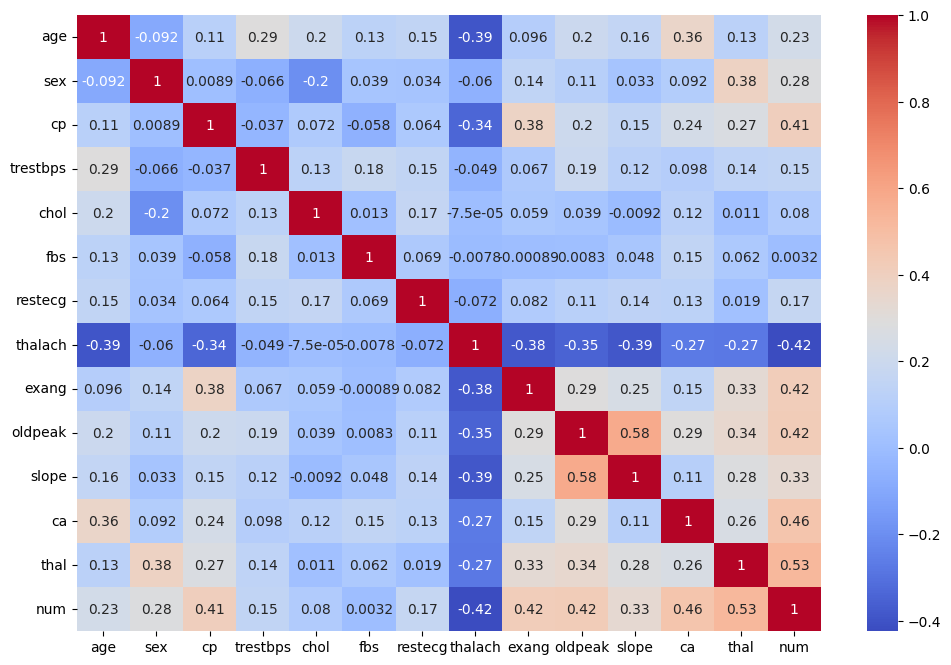

In [ ]:
plt.figure(figsize=(12, 8))
correlation_matrix = heart_disease.corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")
plt.show()

The reds only appear along the diagonal and not in the other other entries implying no strong relationship between predictors. We will therefore use all the predictors in a multiple logistic model.

# **Modelling**

### Multiple Logistic Model

$$P(Y=1)=p(\beta_{0}+\beta_{1}*age+\beta_{2}*sex+\beta_{3}*cp +...+\beta_{13}*thal)=\frac{1}{1+exp(-\beta_{0}-\beta_{1}*age-\beta_{2}*sex-\beta_{3}*cp +...-\beta_{13}*thal)}$$

To fit the model, we need the predictors and outcome variable separated.

We also need to add a constant to the predictor dataset in order to use the logistic regression fit.

In [ ]:
X_data = heart_disease.drop('num', axis=1)

X_with_c = sm.add_constant(X_data)

X_with_c.head()


,const,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,1.0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,1.0,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,1.0,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,1.0,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,1.0,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0


In [ ]:
y = heart_disease['num']

This line will fit a logistic regression to the data.

In [ ]:
logistic_reg = sm.Logit(y, X_with_c).fit()

Optimization terminated successfully.
         Current function value: 0.344594
         Iterations 7


### **Summary of the logistic regression model**

In [ ]:
print(logistic_reg.summary())

                           Logit Regression Results                           
Dep. Variable:                    num   No. Observations:                  297
Model:                          Logit   Df Residuals:                      283
Method:                           MLE   Df Model:                           13
Date:                Wed, 10 Dec 2025   Pseudo R-squ.:                  0.5007
Time:                        11:24:42   Log-Likelihood:                -102.34
converged:                       True   LL-Null:                       -204.97
Covariance Type:            nonrobust   LLR p-value:                 1.136e-36
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -7.3720      2.879     -2.560      0.010     -13.016      -1.728
age           -0.0142      0.024     -0.591      0.555      -0.061       0.033
sex            1.3121      0.488      2.686      0.0

In [ ]:
logistic_reg.aic

np.float64(232.6887038078555)

### **Interpretation**

The p values assocaiated with thal (Thalassemia), ca (Number of major vessels), exang (Exercise-induced angina), thalach (Maximum heart rate achieved), cp (Chest pain type), trestbps(Resting blood pressure) and sex are very small meaning that each of them is statistically significantly associated with probability of getting a heart disease. Of these thalach is negatively associated with heart disease implying that higher maximum heart rate is associated with a lower estimated probability of heart disease, holding the other variables constant.

The pseudo R squared of 0.5007 suggests that the model provides a reasonably good fit to the data.


# **Model Performance**

To understand the model performance, we run some metrics. In particular, precision, accuracy and recall. First we output the confusion matrix which tells how much of the true positives/negatives the model captures and how much of the false positives/negatives the model captures.

Every probability of more than or equal to 0.5 is registered as 1 and less than 0.5 is registered as 0.

In [ ]:
confusion_matrix(y,logistic_reg.predict(X_with_c).round())

array([[140,  20],
       [ 25, 112]])

The confusion matrix indicates that the model correctly captures 140 out of the 160 true negatives (0s) and 112 out of the 137 true positives (1s). It captures 20 negatives as positives and 25 positives as negatives.

In [ ]:
print(classification_report(y,logistic_reg.predict(X_with_c).round()))

              precision    recall  f1-score   support

           0       0.85      0.88      0.86       160
           1       0.85      0.82      0.83       137

    accuracy                           0.85       297
   macro avg       0.85      0.85      0.85       297
weighted avg       0.85      0.85      0.85       297



The overall accuracy of the model is 85%. The precision for 0 is 85% meaning that when the model captures 0s, it is always 85% correct. Similarly to 1s. The model correctly identifies 88% of all truly healthy individuals and 82% of true heart disease.

# **Conclusion**

In this dataset, thal, ca, exang, thalach, cp, trestbps and sex were all statistically significantly associated with the probability of heart disease. Thalach showed a negative association with heart disease.
